# 3º Projeto — Sistemas Inteligentes
## Classificação de Qualidade de Vinhos com k-NN
**Disciplina:** PAM0466 – Sistemas Inteligentes | **Semestre:** 2026.1  
**Docente:** Pedro Thiago Valério de Souza

---
## Atividade 1 — Preparação dos Dados

**Tarefa:** Carregue o dataset e recodifique a variável `quality` em três classes: notas ≤ 5 como *ruim*, 6–7 como *médio* e ≥ 8 como *bom*. Em seguida, normalize todos os atributos utilizando Min-Max ou Z-score.

**Por que a normalização é uma etapa obrigatória para o k-NN?**

* O k-NN classifica cada ponto com base na **distância euclidiana** até seus vizinhos mais próximos. Se os atributos estiverem em escalas muito diferentes — por exemplo, *dióxido de enxofre total* (valores de 0 a ~300) vs. *pH* (valores de 2,7 a 4,0) — os atributos com maior magnitude vão **dominar completamente** o cálculo da distância, tornando os demais praticamente irrelevantes para a classificação. A normalização Min-Max coloca todos os atributos na mesma escala [0, 1], garantindo que cada variável contribua de forma equilibrada para o cálculo da distância.

In [3]:
import urllib.request
urllib.request.urlretrieve(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv',
    'winequality-red.csv'
)
print('CSV baixado!')

CSV baixado!


In [4]:
!pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

#Carregar dataset (coloque o winequality-red.csv na mesma pasta)
df = pd.read_csv('winequality-red.csv', sep=';')
print('Shape:', df.shape)
df.head()


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\Karol\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
# Recodificação em 3 classes
def classify_quality(q):
    if q <= 5:
        return 'ruim'
    elif q <= 7:
        return 'medio'
    else:
        return 'bom'

df['classe'] = df['quality'].apply(classify_quality)

print('=== Distribuição das Classes ===')
contagem = df['classe'].value_counts()
porcentagem = df['classe'].value_counts(normalize=True).mul(100).round(1)
resumo = pd.DataFrame({'Amostras': contagem, 'Percentual (%)': porcentagem})
print(resumo)

=== Distribuição das Classes ===
        Amostras  Percentual (%)
classe                          
medio        837            52.3
ruim         744            46.5
bom           18             1.1


In [6]:
X = df.drop(columns=['quality', 'classe'])
y = df['classe']

# Normalização Min-Max: x' = (x - x_min) / (x_max - x_min)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print('Verificação após normalização (todos devem estar entre 0 e 1):')
pd.DataFrame(X_scaled, columns=X.columns).agg(['min', 'max']).round(4)

Verificação após normalização (todos devem estar entre 0 e 1):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


---
## Atividade 2 — Divisão Treino/Teste

**Tarefa:** Divida os dados em 80% para treino e 20% para teste, utilizando divisão **estratificada** para garantir que a proporção das três classes seja mantida em ambos os conjuntos.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras')
print()
print('Proporção por classe no TREINO:')
print(y_train.value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
print()
print('Proporção por classe no TESTE:')
print(y_test.value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Treino: 1279 amostras | Teste: 320 amostras

Proporção por classe no TREINO:
classe
medio    52.4%
ruim     46.5%
bom       1.1%
Name: proportion, dtype: str

Proporção por classe no TESTE:
classe
medio    52.2%
ruim     46.6%
bom       1.2%
Name: proportion, dtype: str


---
## Atividade 3 — Treinamento e Escolha do k

**Tarefa:** Treine o modelo para diferentes valores de k (1, 3, 5, 7, 11) utilizando validação cruzada de 5 folds sobre o conjunto de treino. Plote a acurácia média em função de k e escolha o valor com melhor desempenho.

**O que acontece com o modelo para valores muito baixos e muito altos de k?**


> - **k muito baixo (ex: k=1):** O modelo classifica cada ponto com base em apenas 1 vizinho. Isso causa **overfitting** — o modelo decora os dados de treino, é extremamente sensível ao ruído e generaliza mal para dados novos.
> - **k muito alto:** O modelo considera vizinhos distantes e irrelevantes, suavizando demais as fronteiras de decisão. Isso causa **underfitting** — o modelo perde capacidade de distinguir classes próximas e, no limite, classifica tudo como a classe majoritária.

In [8]:
k_values = [1, 3, 5, 7, 11]
mean_scores = []
std_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    mean_scores.append(scores.mean())
    std_scores.append(scores.std())
    print(f'k={k:2d} | Acurácia Média: {scores.mean():.4f} | Desvio Padrão: {scores.std():.4f}')

best_k = k_values[np.argmax(mean_scores)]
print(f'\n→ Melhor k escolhido: {best_k} (maior acurácia média na validação cruzada)')

k= 1 | Acurácia Média: 0.7170 | Desvio Padrão: 0.0064
k= 3 | Acurácia Média: 0.6810 | Desvio Padrão: 0.0172
k= 5 | Acurácia Média: 0.6810 | Desvio Padrão: 0.0122
k= 7 | Acurácia Média: 0.6857 | Desvio Padrão: 0.0314
k=11 | Acurácia Média: 0.6998 | Desvio Padrão: 0.0293

→ Melhor k escolhido: 1 (maior acurácia média na validação cruzada)


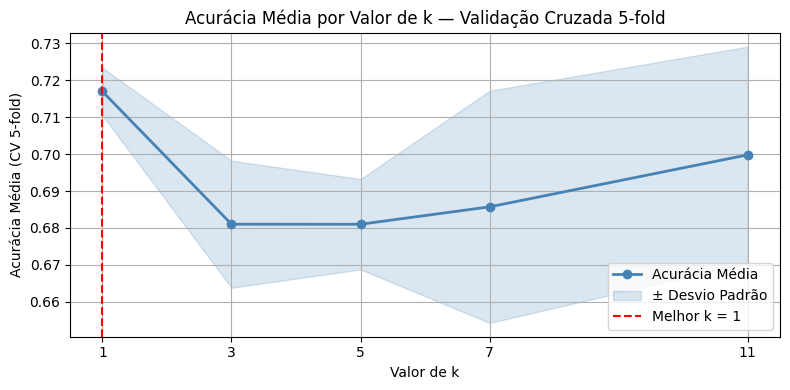

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(k_values, mean_scores, marker='o', color='steelblue', linewidth=2, label='Acurácia Média')
plt.fill_between(
    k_values,
    [m - s for m, s in zip(mean_scores, std_scores)],
    [m + s for m, s in zip(mean_scores, std_scores)],
    alpha=0.2, color='steelblue', label='± Desvio Padrão'
)
plt.axvline(best_k, color='red', linestyle='--', label=f'Melhor k = {best_k}')
plt.xlabel('Valor de k')
plt.ylabel('Acurácia Média (CV 5-fold)')
plt.title('Acurácia Média por Valor de k — Validação Cruzada 5-fold')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Atividade 4 — Avaliação do Modelo

**Tarefa:** Utilizando o conjunto de teste (reservado exclusivamente para esta etapa), calcule a matriz de confusão e as métricas de acurácia, precisão, recall e F1-score para cada classe.

**Entre quais classes o modelo erra com mais frequência?**

* O modelo erra com mais frequência entre as classes **ruim** e **médio**. Isso ocorre porque vinhos com notas 5 e 6 estão no limiar entre as duas classes e possuem perfis químicos muito semelhantes, tornando a separação difícil pelo k-NN. A classe **bom** raramente é predita corretamente pois o dataset é fortemente desbalanceado — apenas ~18 amostras pertencem a essa classe no total —, o que impede o modelo de aprender suas características de forma adequada.

In [10]:
# Treinar o modelo final com o melhor k e avaliar no conjunto de teste
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)

print(f'Acurácia no Conjunto de Teste (k={best_k}): {accuracy_score(y_test, y_pred):.4f}')
print()
print('=== Relatório de Classificação ===')
print(classification_report(y_test, y_pred, target_names=['bom', 'medio', 'ruim'], zero_division=0))

Acurácia no Conjunto de Teste (k=1): 0.7750

=== Relatório de Classificação ===
              precision    recall  f1-score   support

         bom       0.00      0.00      0.00         4
       medio       0.77      0.80      0.79       167
        ruim       0.78      0.77      0.77       149

    accuracy                           0.78       320
   macro avg       0.52      0.52      0.52       320
weighted avg       0.77      0.78      0.77       320



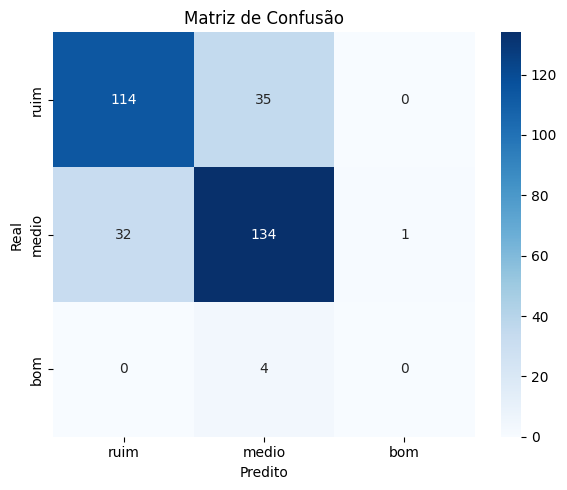

In [ ]:
classes = ['ruim', 'medio', 'bom']
cm = confusion_matrix(y_test, y_pred, labels=classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title(f'Matriz de Confusão — k = {best_k}')
plt.tight_layout()
plt.show()

---
## Conclusões

O k-NN demonstrou desempenho **moderado** neste problema de classificação de vinhos.

**Principais limitações identificadas:**
- **Desbalanceamento de classes:** A classe *bom* tem apenas ~18 amostras (1,1% do dataset), impedindo o modelo de aprender suas características.
- **Maldição da dimensionalidade:** Com 11 atributos, as distâncias euclidianas tendem a se homogeneizar, reduzindo o poder discriminativo do k-NN.
- **Fronteira ambígua:** Vinhos com notas 5 e 6 possuem perfis químicos muito semelhantes, dificultando a separação entre *ruim* e *médio*.

**Melhorias sugeridas:**
- Aplicar **SMOTE** para balancear as classes minoritárias.
- Testar algoritmos mais robustos como **Random Forest** ou **SVM**.
- Realizar **seleção de atributos** para reduzir a dimensionalidade.